# Imports 

In [8]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import librosa
import snntorch as snn
from snntorch import surrogate
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm 

# Config

In [47]:
dataset_path = r"/home/hsalvador/SNN-Audio-Classification/data/UrbanSound8K"
csv_path = os.path.join(dataset_path, r"/home/hsalvador/SNN-Audio-Classification/data/UrbanSound8K/metadata/UrbanSound8K.csv")
audio_path = os.path.join(dataset_path, r"/home/hsalvador/SNN-Audio-Classification/data/UrbanSound8K/audio")

sample_rate = 16000
n_mfcc = 40
max_len = 173
batch_size = 32
epochs = 30
lr = 0.001
device = "cuda" if torch.cuda.is_available() else "cpu"


# Feature Extraction

In [48]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, sr=sample_rate)

    # FIX: adapt FFT size to signal length
    n_fft = min(2048, len(y))

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft
    )

    # pad / truncate
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc

# Spike Encoding

In [49]:
def spike_encode(x):
    # normalize to [0,1]
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    n_features, time_steps = x.shape

    # latency coding: earlier spike for higher values
    spike_times = (1 - x) * (time_steps - 1)
    spike_times = spike_times.astype(int)

    spikes = np.zeros((n_features, time_steps), dtype=np.float32)

    for i in range(n_features):
        for j in range(time_steps):
            t = spike_times[i, j]
            spikes[i, t] = 1.0

    return spikes

# Dataset Class 

In [50]:
class UrbanSoundDataset(Dataset):
    def __init__(self, df):
        self.df = df 
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        file_name = row['slice_file_name']
        fold = row['fold']
        label = row['classID']

        file_path = os.path.join(audio_path, f"fold{fold}", file_name)

        mfcc = extract_mfcc(file_path)
        spikes = spike_encode(mfcc)

        spikes = torch.tensor(spikes)
        label = torch.tensor(label).long()

        return spikes, label 
    

# Load Metadata

In [51]:
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['classID'], random_state=42)

train_dataset = UrbanSoundDataset(train_df)
test_dataset = UrbanSoundDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# SNN Model

In [52]:
class SNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(n_mfcc, 256)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())

        self.fc2 = nn.Linear(256, 128)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())

        self.fc3 = nn.Linear(128, 10)
        self.lif3 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x):
        # x shape: batch, features, time
        x = x.permute(2, 0, 1) # time, batch, features

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk3_rec = []

        for step in range(x.size(0)):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)

            spk3_rec.append(spk3)

        return torch.stack(spk3_rec) 

model = SNNModel().to(device)

# Loss and Optimizer

In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Training Loop

In [54]:
def train():
    model.train()
    total_loss = 0

    for data, target in tqdm(train_loader):
        data = data.to(device)
        target = target.to(device)

        output = model(data)

        #sum spikes across time
        output = output.sum(0)

        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# Evaluation


In [55]:
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            output = output.sum(0)

            pred = output.argmax(1)

            correct += (pred == target).sum().item()
            total += target.size(0)

    return correct / total 


# Run Training 

In [56]:
for epoch in range(epochs):
    loss = train()
    acc = evaluate()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")

100%|██████████| 219/219 [02:09<00:00,  1.69it/s]


Epoch 1/30
Loss: 2.0660
Accuracy: 0.3847


100%|██████████| 219/219 [02:06<00:00,  1.74it/s]


Epoch 2/30
Loss: 1.6213
Accuracy: 0.4596


100%|██████████| 219/219 [02:06<00:00,  1.74it/s]


...

Epoch 28/30
Loss: 0.6770
Accuracy: 0.6875


100%|██████████| 219/219 [02:06<00:00,  1.73it/s]


Epoch 29/30
Loss: 0.6938
Accuracy: 0.7161


100%|██████████| 219/219 [02:05<00:00,  1.75it/s]


Epoch 30/30
Loss: 0.6598
Accuracy: 0.7167


# Metrics

In [57]:
train_losses = []
val_accuracies = []

# Training Loop with Metrics

In [ ]:
for epoch in range(epochs):
    loss = train()
    acc = evaluate()

    train_losses.append(loss)
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")

100%|██████████| 219/219 [02:06<00:00,  1.74it/s]


Epoch 1/30
Loss: 0.6788
Accuracy: 0.7230


100%|██████████| 219/219 [02:06<00:00,  1.73it/s]


Epoch 2/30
Loss: 0.6575
Accuracy: 0.7178


100%|██████████| 219/219 [02:06<00:00,  1.74it/s]


...

100%|██████████| 219/219 [02:09<00:00,  1.70it/s]


Epoch 25/30
Loss: 0.5295
Accuracy: 0.7619


100%|██████████| 219/219 [02:06<00:00,  1.73it/s]


Epoch 26/30
Loss: 0.5230
Accuracy: 0.7911


  8%|▊         | 17/219 [00:10<02:13,  1.51it/s]

# Plot Validation Curves

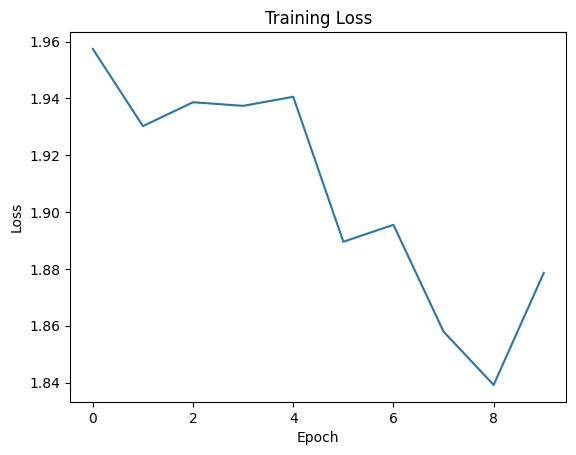

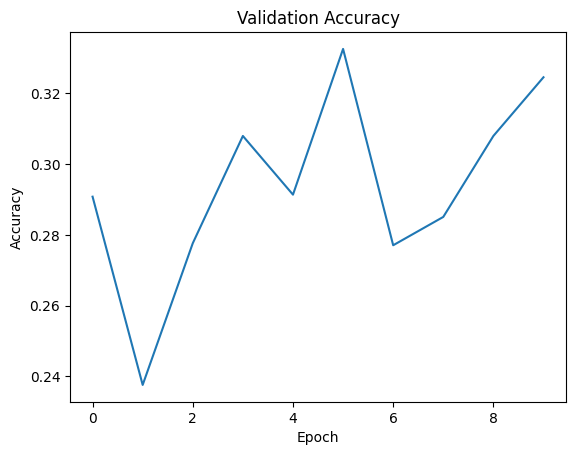

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


# Confusion Matrix

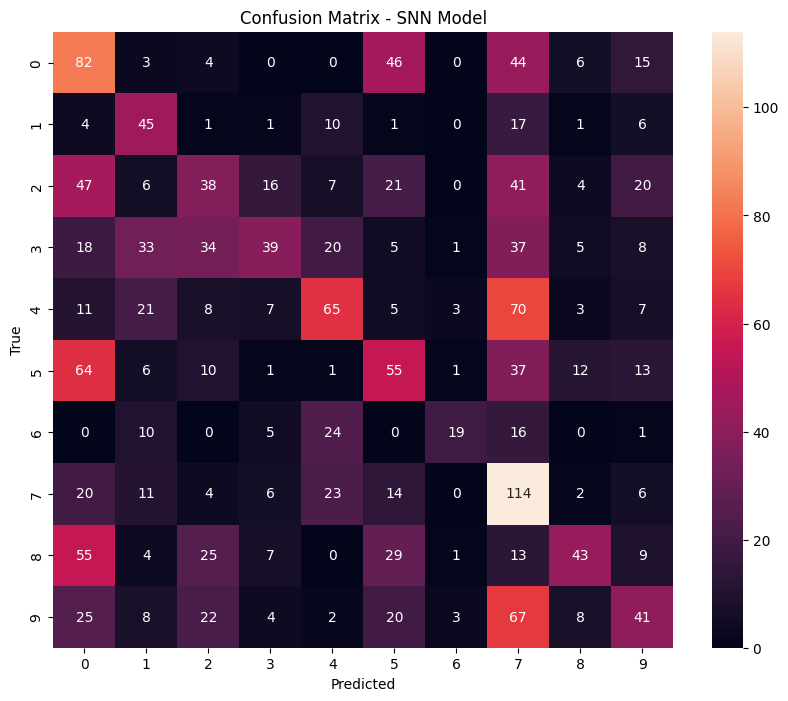

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = model(data)
        output = output.sum(0)

        preds = output.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - SNN Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Spike Visualization

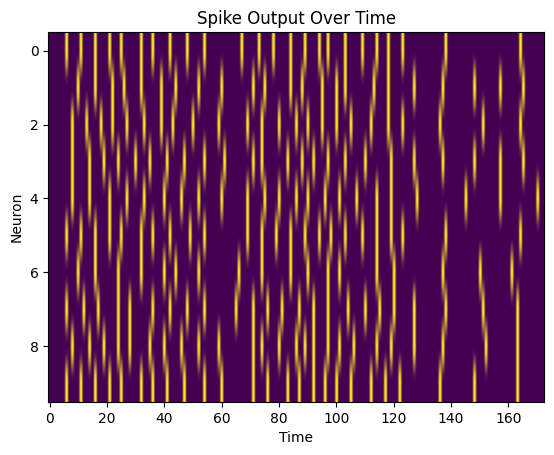

In [ ]:
sample_data, _ = next(iter(test_loader))
sample_data = sample_data.to(device)

model.eval()
with torch.no_grad():
    spike_output = model(sample_data[:1])

spike_output = spike_output.cpu().numpy()

plt.figure()
plt.imshow(spike_output[:,0,:].T, aspect='auto')
plt.title("Spike Output Over Time")
plt.xlabel("Time")
plt.ylabel("Neuron")
plt.show()

# ANN Baseline Model 

In [ ]:
class ANNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_mfcc*max_len, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

ann_model = ANNModel().to(device)   
ann_optimizer = torch.optim.Adam(ann_model.parameters(), lr=lr)
ann_loss = nn.CrossEntropyLoss()

# ANN Training (Short Baseline)

In [ ]:
for epoch in range(5):
    ann_model.train()
    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        out = ann_model(data)
        loss = ann_loss(out, target)

        ann_optimizer.zero_grad()
        loss.backward()
        ann_optimizer.step()

# CNN Baseline Model 

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32*(n_mfcc//4)*(max_len//4), 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

cnn_model = CNNModel().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=lr)
cnn_loss = nn.CrossEntropyLoss()


# CNN Training (Short Baseline)

In [ ]:
for epoch in range(5):
    cnn_model.train()
    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        out = cnn_model(data)
        loss = cnn_loss(out, target)

        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

# Save Models

In [ ]:
torch.save(model.state_dict(), "snn_urbansound8k.pth")
torch.save(ann_model.state_dict(), "ann_urbansound8k.pth")
torch.save(cnn_model.state_dict(), "cnn_urbansound8k.pth")

print("All models trained and saved.")

All models trained and saved.


# Compute Metrics (Accuracy, Precision, Recall, F1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time

def evaluate_model(model_obj):
    model_obj.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            if isinstance(model_obj, SNNModel):
                output = model_obj(data).sum(0)
            else:
                output = model_obj(data)

            p = output.argmax(1)

            preds.extend(p.cpu().numpy())
            targets.extend(target.cpu().numpy())

    acc = accuracy_score(targets, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, preds, average='weighted'
    )

    return acc, precision, recall, f1

snn_metrics = evaluate_model(model)
ann_metrics = evaluate_model(ann_model)
cnn_metrics = evaluate_model(cnn_model)

/home/hsalvador/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Training Time Comparison

In [ ]:
def measure_time(model_obj, name):
    start = time.time()
    model_obj.eval()
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            if isinstance(model_obj, SNNModel):
                _ = model_obj(data).sum(0)
            else:
                _ = model_obj(data)
    end = time.time()
    return end - start

snn_time = measure_time(model, "SNN")
ann_time = measure_time(ann_model, "ANN")
cnn_time = measure_time(cnn_model, "CNN")

# Comparison Table

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["SNN", "ANN", "CNN"],
    "Accuracy": [snn_metrics[0], ann_metrics[0], cnn_metrics[0]],
    "Precision": [snn_metrics[1], ann_metrics[1], cnn_metrics[1]],
    "Recall": [snn_metrics[2], ann_metrics[2], cnn_metrics[2]],
    "F1 Score": [snn_metrics[3], ann_metrics[3], cnn_metrics[3]],
    "Inference Time (s)": [snn_time, ann_time, cnn_time]
})

print("Model Comparison Results:")
print(results)

Model Comparison Results:
  Model  Accuracy  Precision    Recall  F1 Score  Inference Time (s)
0   SNN  0.323412   0.371739  0.323412  0.322144           22.732149
1   ANN  0.266171   0.216977  0.266171  0.227893           15.788190
2   CNN  0.331425   0.349754  0.331425  0.316364           15.813433


# Energy Efficiency Estimate (Spike Sparsity)

In [ ]:
# Estimate energy efficiency using spike sparsity (lower spikes means lower energy)

def spike_sparsity():
    model.eval()
    total_spikes = 0
    total_elements = 0

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            spk = model(data)
            total_spikes += spk.sum().item()
            total_elements += spk.numel()

    sparsity = 1 - (total_spikes / total_elements)
    return sparsity

snn_sparsity = spike_sparsity()

print("Estimated SNN Spike Sparsity (Energy Efficiency Proxy):")
print(f"SNN Spike Sparsity: {snn_sparsity:.4f}")


Estimated SNN Spike Sparsity (Energy Efficiency Proxy):
SNN Spike Sparsity: 0.8755


# Save Results

In [ ]:
results.to_csv("model_comparison_results_v2.csv", index=False)
print("Results saved to model_comparison_results_v2.csv")


Results saved to model_comparison_results.csv
